# 🔎 Auto-EDA Dashboard - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/auto-eda/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/auto-eda/demo.ipynb)

> *"We waste 2 hours profiling every new dataset."*

Drop in a DataFrame, get the whole first-look automatically: shape, missingness, dtypes,
cardinality, distributions, correlations, and **quality flags** worth a human's attention.

**What we cover**
1. A messy sample dataset
2. Semantic type inference (beyond dtype)
3. Per-column profiles
4. Auto quality flags
5. Distributions + correlations, visualized


## Step 1 - A realistically messy dataset

Mixed types, missing values, an all-empty column - just like a fresh export.


In [1]:
from __future__ import annotations
from typing import Any, Dict, List
import numpy as np, pandas as pd

rng = np.random.default_rng(42); n = 300
df = pd.DataFrame({
    "customer_id": range(1, n+1),
    "age": rng.integers(18, 75, n),
    "plan": rng.choice(["free","pro","enterprise"], n, p=[.6,.3,.1]),
    "monthly_spend": np.round(rng.gamma(2, 30, n), 2),
    "region": rng.choice(["NA","EU","APAC"], n),
    "signup_source": rng.choice(["organic","ads","referral",None], n, p=[.4,.3,.2,.1]),
    "is_active": rng.choice([True, False], n, p=[.7,.3]),
    "notes": [None]*n,                      # all-empty -> should be flagged
})
df.head()

,customer_id,age,plan,monthly_spend,region,signup_source,is_active,notes
0,1,23,pro,70.73,NA,referral,True,None
1,2,62,pro,7.33,NA,ads,True,None
2,3,55,free,30.04,APAC,ads,True,None
3,4,43,free,18.96,EU,None,True,None
4,5,42,free,68.47,APAC,organic,True,None


## Step 2 - Infer semantic type

The raw dtype isn't enough: an object column might be a *category* or free *text*. We
decide by cardinality ratio. IDs, categories, and text get handled differently downstream.


In [2]:
def infer_kind(s: pd.Series) -> str:
    if pd.api.types.is_bool_dtype(s): return "boolean"
    if pd.api.types.is_datetime64_any_dtype(s): return "datetime"
    if pd.api.types.is_numeric_dtype(s): return "numeric"
    nn = s.dropna()
    if nn.empty: return "empty"
    return "categorical" if nn.nunique()/len(nn) < 0.5 else "text"

for col in df.columns:
    print(f"{col:14s} dtype={str(df[col].dtype):8s} -> {infer_kind(df[col])}")

customer_id    dtype=int64    -> numeric
age            dtype=int64    -> numeric
plan           dtype=object   -> categorical
monthly_spend  dtype=float64  -> numeric
region         dtype=object   -> categorical
signup_source  dtype=object   -> categorical
is_active      dtype=bool     -> boolean
notes          dtype=object   -> empty


## Step 3 - Per-column profiles

Missingness, cardinality, and type-appropriate stats (numeric summary vs top categories).


In [3]:
def profile_column(s: pd.Series) -> Dict[str, Any]:
    n = len(s); nn = s.dropna(); kind = infer_kind(s)
    p = {"name": s.name, "kind": kind, "missing_pct": round(100*s.isna().sum()/n,1),
         "unique": int(nn.nunique()),
         "unique_pct": round(100*nn.nunique()/len(nn),1) if len(nn) else 0.0}
    if kind == "numeric":
        p.update(mean=round(float(nn.mean()),2) if len(nn) else None,
                 min=float(nn.min()) if len(nn) else None,
                 max=float(nn.max()) if len(nn) else None)
    elif kind in {"categorical","boolean","text"}:
        p["top_values"] = [{"value":str(k),"count":int(v)} for k,v in nn.value_counts().head(3).items()]
    return p

profiles = [profile_column(df[c]) for c in df.columns]
pd.DataFrame([{ "column":p["name"],"kind":p["kind"],"missing %":p["missing_pct"],
               "unique":p["unique"],"unique %":p["unique_pct"]} for p in profiles])

,column,kind,missing %,unique,unique %
0,customer_id,numeric,0.0,300,100.0
1,age,numeric,0.0,56,18.7
2,plan,categorical,0.0,3,1.0
3,monthly_spend,numeric,0.0,296,98.7
4,region,categorical,0.0,3,1.0
5,signup_source,categorical,12.7,3,1.1
6,is_active,boolean,0.0,2,0.7
7,notes,empty,100.0,0,0.0


## Step 4 - Automatic quality flags

The actionable part: what would a careful analyst circle in red? Heavy missingness,
constant columns, ID-looking categories, duplicate rows.


In [4]:
def quality_flags(df, profiles) -> List[Dict[str,str]]:
    flags = []; n = len(df)
    if df.duplicated().sum():
        flags.append({"severity":"warning","column":"(table)","message":f"{int(df.duplicated().sum())} duplicate rows."})
    for p in profiles:
        col = str(p["name"])
        if p["missing_pct"] >= 50:
            flags.append({"severity":"error","column":col,"message":f"{p['missing_pct']}% missing - mostly empty."})
        elif p["missing_pct"] >= 20:
            flags.append({"severity":"warning","column":col,"message":f"{p['missing_pct']}% missing."})
        if p["unique"] <= 1 and n > 1:
            flags.append({"severity":"warning","column":col,"message":"constant column - no signal."})
        if p["kind"]=="categorical" and p["unique_pct"]>=95 and n>20:
            flags.append({"severity":"info","column":col,"message":"near-unique - looks like an ID."})
    return flags

emoji = {"error":"🔴","warning":"🟡","info":"🔵"}
for f in quality_flags(df, profiles):
    print(f"{emoji[f['severity']]} {f['column']}: {f['message']}")

🔴 notes: 100.0% missing - mostly empty.
🟡 notes: constant column - no signal.


## Step 5 - Distributions + correlations, visualized

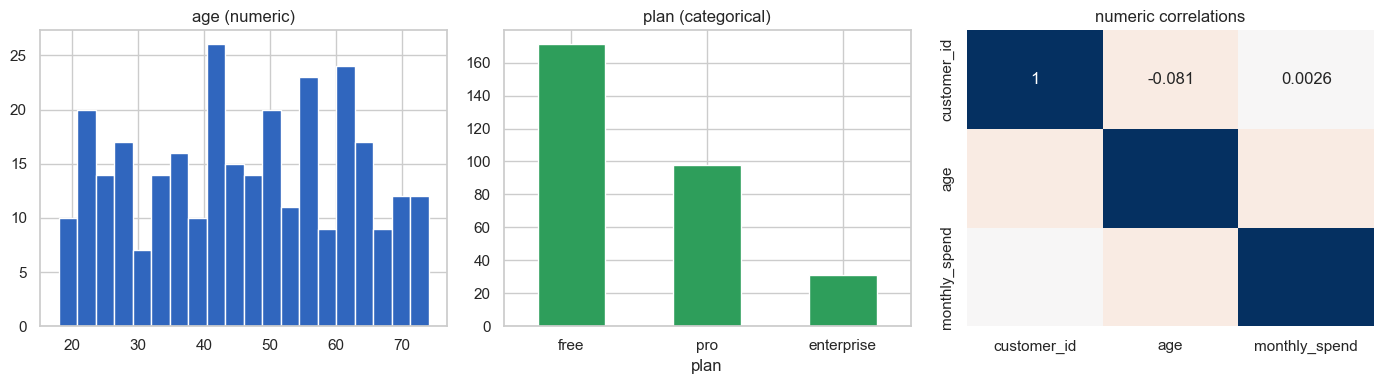

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df["age"], bins=20, color="#3066be"); axes[0].set_title("age (numeric)")
df["plan"].value_counts().plot.bar(ax=axes[1], color="#2e9e5b"); axes[1].set_title("plan (categorical)")
axes[1].tick_params(axis="x", rotation=0)
num = df.select_dtypes("number")
sns.heatmap(num.corr(), annot=True, cmap="RdBu", center=0, ax=axes[2], cbar=False)
axes[2].set_title("numeric correlations")
plt.tight_layout(); plt.savefig("eda.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- **Semantic typing** goes beyond dtype (categorical vs text vs ID).
- **Per-column profiles** give missingness, cardinality, and the right stats per type.
- **Quality flags** surface the problems a human should look at first.

This is the engine behind the Streamlit app in `app.py`. For a full HTML report,
`ydata-profiling` is the heavyweight tool; this core is fast and embeddable.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the dashboard:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
Upload any CSV and get an instant profile.
